## [1. Import Needed Modules](#import) ##
## [2. Resize and store all images into working directory](#resize) ##
## [3. Read in resized images and create a dataframe of image paths and class labels](#makedf) ##
## [4. Balance train_df using the balance function](#trim) ##
## [5. Create train, test and validation generators](#generators) ##
## [6. Create a function to show Training Image Samples](#show) ##
## [7. Create the Model](#model) ##
## [8. Create a custom Keras callback to continue or halt training](#callback) ##
## [9. Instantiate custom callback and create callbacks to control learning rate and early stopping](#callbacks) ##
## [10. Train the model](#train) ##
## [11. Define a function to plot the training data](#plot) ##
## [12. Make predictions on test set, create Confusion Matrix and Classification Report](#result) ##
## [13 Save the model](#save) ##


<a id="import"></a>
# <center>Import Need Modules</center>

In [ ]:
# Google Colab specific imports
from google.colab import drive

# Core libraries
import numpy as np
import pandas as pd
import os
import time
import shutil

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Visualization
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')

# Machine Learning
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Enable mixed precision for faster training on GPU
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

# Keras modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU detected! Training will be fast.")
else:
    print("No GPU detected. Training will be slow.")

Compute dtype: float16
Variable dtype: float32
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected! Training will be fast.


### The size of the images are very large. If you try to use the full image size training will take a very long time. Therefore you
### want to reduce the image size. However if you include resizing of images as part of training it requires each image to be repeatedly
### resized in each epoch. This also make the training times to be large. It is more efficient to resize all the images FIRST and save them.
### Then use these images for training.

<a id="resize"></a>
# <center>Resize all images and save to the working directory</center>

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

start_time=time.time()
sdir = '/content/drive/MyDrive/dataset'
working_dir = '/content/cauliflower_training/'
img_height = 300
img_width = 300

# Create working directory first
os.makedirs(working_dir, exist_ok=True)

save_path = os.path.join(working_dir, 'cali')

if os.path.isdir(save_path):
    shutil.rmtree(save_path) # if the directory exists remove it

os.makedirs(save_path, exist_ok=True)  # Changed from os.mkdir() to os.makedirs()

classlist = sorted(os.listdir(sdir))
for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if not os.path.isdir(classpath):  # skip if not a directory
        continue
    print('processing ', klass,  ' class')
    class_dest_path = os.path.join(save_path, klass)
    os.makedirs(class_dest_path, exist_ok=True)  # Changed here too
    flist = os.listdir(classpath)
    for f in flist:
        fpath = os.path.join(classpath,f)
        f_dest_path = os.path.join(class_dest_path, f)
        try: # make sure images are correct image files
            img = cv2.imread(fpath)
            img = cv2.resize(img, (img_height, img_width))
            cv2.imwrite(f_dest_path, img)
        except:
            print('Image ', fpath, ' is an invalid image file')

tr_duration = time.time() - start_time
hours = tr_duration // 3600
minutes = (tr_duration - (hours * 3600)) // 60
seconds = tr_duration - ((hours * 3600) + (minutes * 60))
msg = f'resizing elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
print(msg, flush=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
processing  Alternaria Leaf Spot  class
processing  Bacterial Soft Rot  class
processing  Black Rot  class
processing  Black Spot  class
processing  Downy Mildew  class
processing  Healthy  class
resizing elapsed time was 0.0 hours,  3.0 minutes, 20.65 seconds)


<a id="makedf"></a>
# <center>Read in resized images and create a dataframe of image paths and class labels</center>

In [ ]:
def make_df(save_path):
    classlist=os.listdir(save_path)
    filepaths=[]
    labels=[]
    for klass in classlist:
        classpath=os.path.join(save_path, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    df=pd.concat([Fseries, Lseries], axis=1)
    train_df, dummy_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df=train_test_split(dummy_df,train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
    print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
    # get the number of classes and the images count for each class in train_df
    classes=sorted(list(train_df['labels'].unique()))
    class_count = len(classes)
    print('The number of classes in the dataset is: ', class_count)
    groups=train_df.groupby('labels')
    print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
    countlist=[]
    classlist=[]
    for label in sorted(list(train_df['labels'].unique())):
        group=groups.get_group(label)
        countlist.append(len(group))
        classlist.append(label)
        print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

    # get the classes with the minimum and maximum number of train images
    max_value=np.max(countlist)
    max_index=countlist.index(max_value)
    max_class=classlist[max_index]
    min_value=np.min(countlist)
    min_index=countlist.index(min_value)
    min_class=classlist[min_index]
    print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
    # lets get the average height and width of a sample of the train images
    ht=0
    wt=0
    # select 100 random samples of train_df
    train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
    for i in range (len(train_df_sample)):
        fpath=train_df_sample['filepaths'].iloc[i]
        img=plt.imread(fpath)
        shape=img.shape
        ht += shape[0]
        wt += shape[1]
    print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)
    return train_df, test_df, valid_df, classes
train_df, test_df, valid_df, classes = make_df(save_path)
class_count=len(classes)

train_df lenght:  6725   test_df length:  841   valid_df length:  841
The number of classes in the dataset is:  6
            CLASS               IMAGE COUNT 
     Alternaria Leaf Spot          1206     
      Bacterial Soft Rot           1121     
          Black Rot                 640     
          Black Spot                201     
         Downy Mildew              1029     
           Healthy                 2528     
Healthy  has the most images=  2528   Black Spot  has the least images=  201
average height=  300  average width=  300 aspect ratio=  1.0


<a id="balance"></a>
# <center>Expand train_df by creating augmented images</center>


In [ ]:
def balance(df, n, working_dir, img_size):
    df=df.copy()
    print('Initial length of dataframe is ', len(df))
    aug_dir=os.path.join(working_dir, 'aug')# directory to store augmented images
    if os.path.isdir(aug_dir):# start with an empty directory
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    for label in df['labels'].unique():
        dir_path=os.path.join(aug_dir,label)
        os.mkdir(dir_path) # make class directories within aug directory
    # create and store the augmented images
    total=0
    gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2)
    groups=df.groupby('labels') # group by class
    for label in df['labels'].unique():  # for every class
        group=groups.get_group(label)  # a dataframe holding only rows with the specified label
        sample_count=len(group)   # determine how many samples there are in this class
        if sample_count< n: # if the class has less than target number of images
            aug_img_count=0
            delta=n - sample_count  # number of augmented images to create
            target_dir=os.path.join(aug_dir, label)  # define where to write the images
            msg='{0:40s} for class {1:^30s} creating {2:^5s} augmented images'.format(' ', label, str(delta))
            print(msg, '\r', end='') # prints over on the same line
            aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=img_size,
                                            class_mode=None, batch_size=1, shuffle=False,
                                            save_to_dir=target_dir, save_prefix='aug-', color_mode='rgb',
                                            save_format='jpg')
            while aug_img_count<delta:
                images=next(aug_gen)
                aug_img_count += len(images)
            total +=aug_img_count
    print('Total Augmented images created= ', total)
    # create aug_df and merge with train_df to create composite training set ndf
    aug_fpaths=[]
    aug_labels=[]
    classlist=os.listdir(aug_dir)
    for klass in classlist:
        classpath=os.path.join(aug_dir, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)
    Fseries=pd.Series(aug_fpaths, name='filepaths')
    Lseries=pd.Series(aug_labels, name='labels')
    aug_df=pd.concat([Fseries, Lseries], axis=1)
    df=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
    print('Length of augmented dataframe is now ', len(df))
    return df

n=200 # number of samples in each class
working_dir=r'./' # directory to store augmented images
img_size=(300,300) # size of augmented images
train_df=balance(train_df, n, working_dir, img_size)

Initial length of dataframe is  6725
Total Augmented images created=  0
Length of augmented dataframe is now  6725


<a id="generators"></a>
# <center>Create the train_gen, test_gen final_test_gen and valid_gen</center>

In [ ]:
batch_size=80 # We will use and EfficientetB3 model, with image size of (200, 250) this size should not cause resource error
trgen=ImageDataGenerator(horizontal_flip=True,rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2 )
t_and_v_gen=ImageDataGenerator()
msg='{0:70s} for train generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
msg='{0:70s} for valid generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)
# for the test_gen we want to calculate the batch size and test steps such that batch_size X test_steps= number of samples in test set
# this insures that we go through all the sample in the test set exactly once.
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
msg='{0:70s} for test generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)
# from the generator we can get information we will need later
classes=list(train_gen.class_indices.keys())
class_indices=list(train_gen.class_indices.values())
class_count=len(classes)
labels=test_gen.labels
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

Found 6724 validated image filenames belonging to 6 classes.
Found 841 validated image filenames belonging to 6 classes.
Found 841 validated image filenames belonging to 6 classes.
test batch size:  29   test steps:  29  number of classes :  6


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(


<a id="show"></a>
# <center>Create a function to show example training images</center>

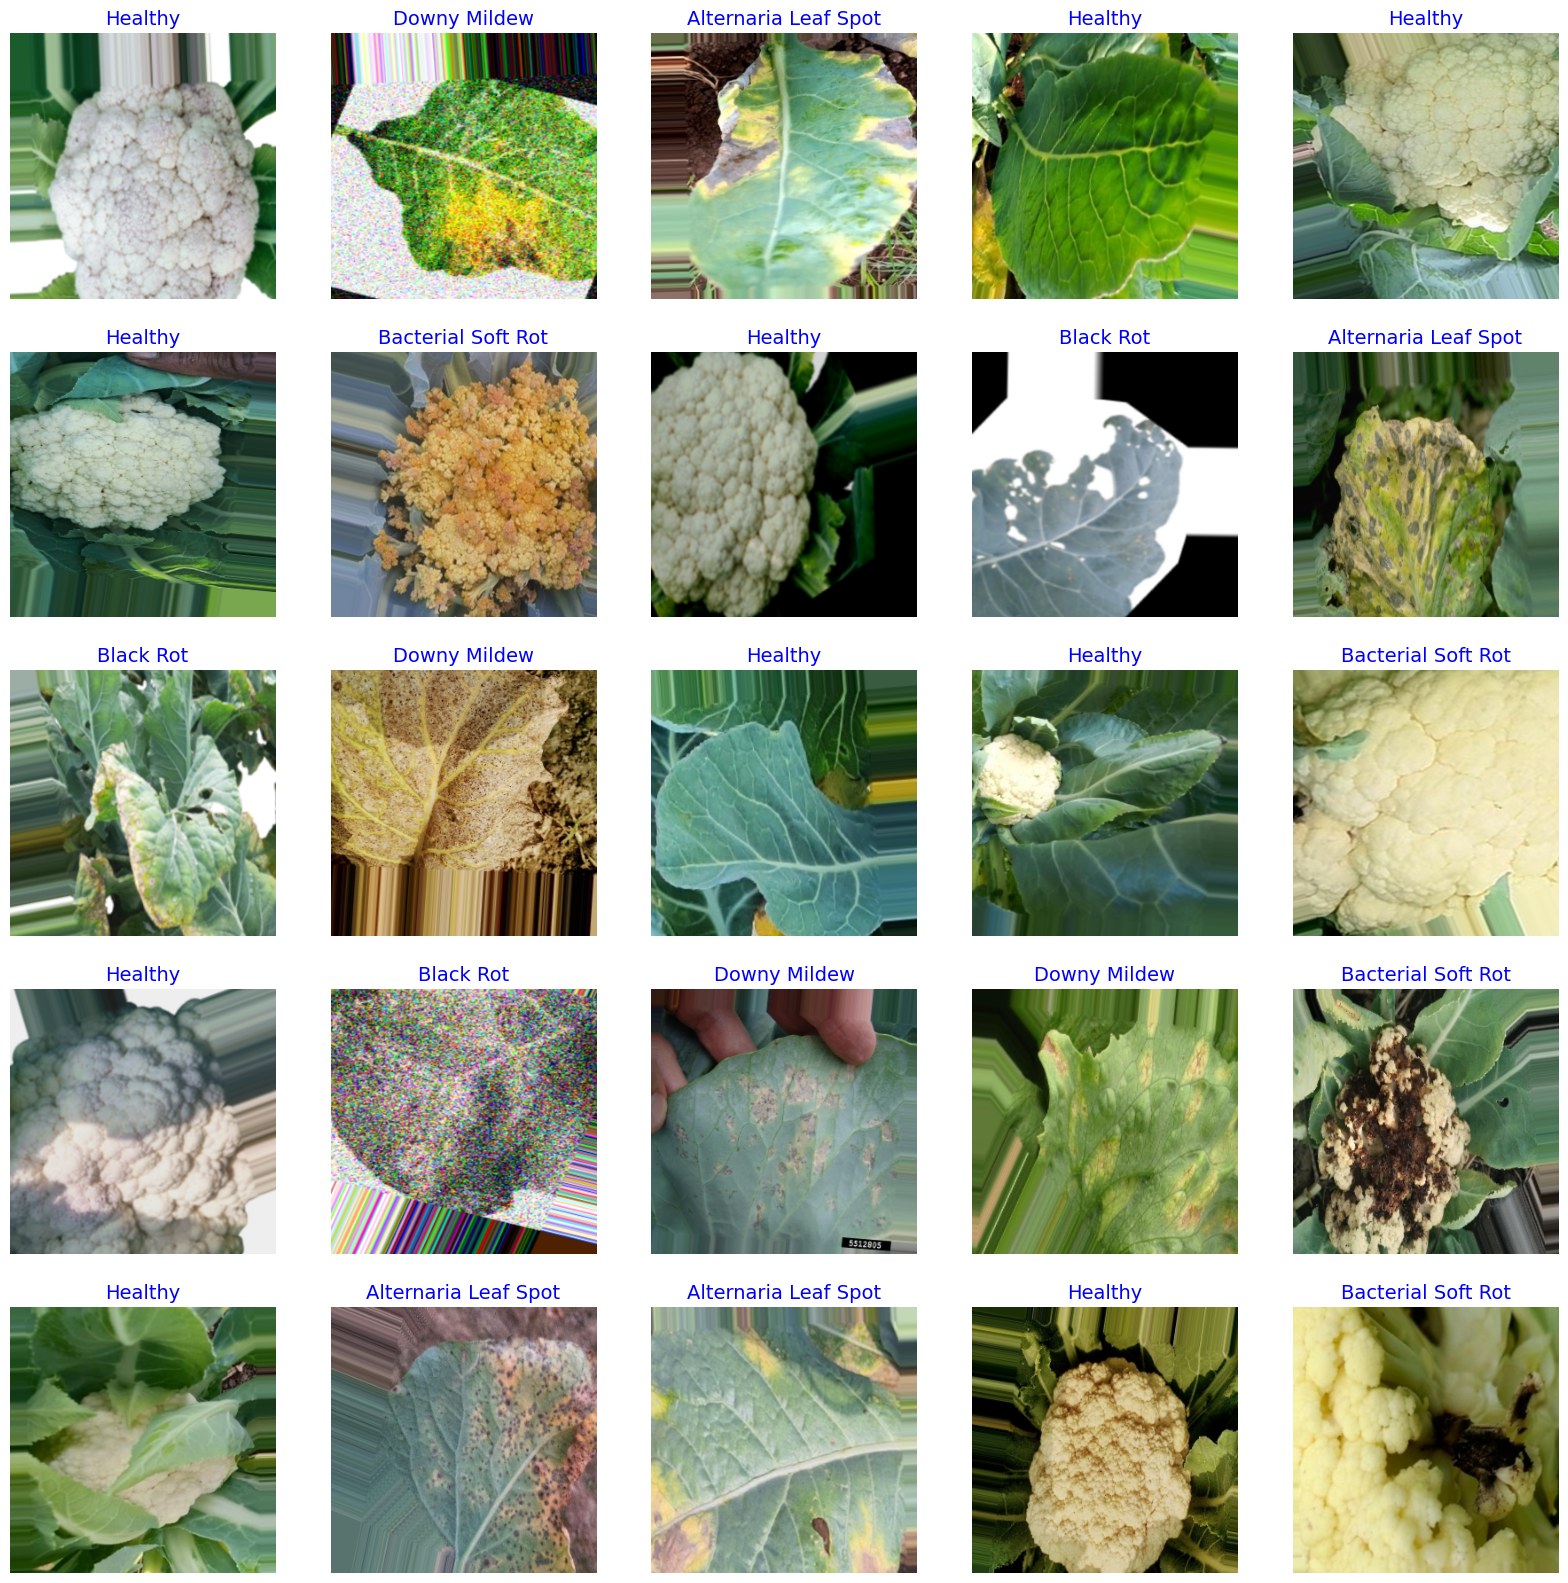

In [ ]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )

<a id="model"></a>
# <center>Create a model using transfer learning with EfficientNetB3</center>
### NOTE experts advise you make the base model initially not trainable. Then train for some number of epochs
### then fine tune model by making base model trainable and run more epochs
### I have found this to be WRONG!!!!
### Making the base model trainable from the outset leads to faster convegence and a lower validation loss
### for the same number of total epochs!

In [ ]:
img_shape = (img_size[0], img_size[1], 3)
model_name = 'EfficientNetB3'

# Create base model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, dtype='float32')(x)
x = Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu')(x)
x = Dropout(rate=.4, seed=123)(x)

# FIX: Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
lr = .001
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Verify the fix
print("✅ Model output dtype:", model.output.dtype)
print("✅ Model compiled successfully!")

<a id="callback"></a>
# <center>Create a custom Keras callback to continue and optionally set LR or halt training</center>
The LR_ASK callback is a convenient callback that allows you to continue training for ask_epoch more epochs or to halt training.  
If you elect to continue training for more epochs you are given the option to retain the current learning rate (LR) or to  
enter a new value for the learning rate. The form of use is:  
ask=LR_ASK(model,epochs, ask_epoch) where:  
* model is a string which is the name of your compiled model
* epochs is an integer which is the number of epochs to run specified in model.fit
* ask_epoch is an integer. If ask_epoch is set to a value say 5 then the model will train for 5 epochs.  
  then the user is ask to enter H to halt training, or enter an inter value. For example if you enter 4  
  training will continue for 4 more epochs to epoch 9 then you will be queried again. Once you enter an  
  integer value you are prompted to press ENTER to continue training using the current learning rate  
  or to enter a new value for the learning rate.  
  
 At the end of training the model weights are set to the weights for the epoch that achieved the lowest validation loss

In [ ]:
class LR_ASK(keras.callbacks.Callback):
    def __init__ (self, model, epochs,  ask_epoch): # initialization of the callback
        super(LR_ASK, self).__init__()
        self.user_model=model  # Changed from self.model to self.user_model
        self.ask_epoch=ask_epoch
        self.epochs=epochs
        self.ask=True # if True query the user on a specified epoch
        self.lowest_vloss=np.inf
        self.best_weights=self.user_model.get_weights() # Changed to self.user_model
        self.best_epoch=1


    def on_train_begin(self, logs=None): # this runs on the beginning of training
        if self.ask_epoch == 0:
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch=1
        if self.ask_epoch >= self.epochs: # you are running for epochs but ask_epoch>epochs
            print('ask_epoch >= epochs, will train for ', epochs, ' epochs', flush=True)
            self.ask=False # do not query the user
        if self.epochs == 1:
            self.ask=False # running only for 1 epoch so do not query user
        else:
            print('Training will proceed until epoch', ask_epoch,' then you will be asked to')
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')
        self.start_time= time.time() # set the time at which training started

    def on_train_end(self, logs=None):   # runs at the end of training
        print('loading model with weights from epoch ', self.best_epoch)
        self.user_model.set_weights(self.best_weights) # Changed to self.user_model
        tr_duration=time.time() - self.start_time   # determine how long the training cycle lasted
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print (msg, flush=True) # print out training duration time

    def on_epoch_end(self, epoch, logs=None):  # method runs on the end of each epoch
        v_loss=logs.get('val_loss')  # get the validation loss for this epoch
        if v_loss< self.lowest_vloss:
            self.lowest_vloss=v_loss
            self.best_weights=self.user_model.get_weights() # Changed to self.user_model
            self.best_epoch=epoch + 1
            print (f'\n validation loss of {v_loss:7.4f} is below lowest loss, saving weights from epoch {str(epoch + 1):3s} as best weights')
        else:
            print (f'\n validation loss of {v_loss:7.4f} is above lowest loss of {self.lowest_vloss:7.4f} keeping weights from epoch {str(self.best_epoch)} as best weights')

        if self.ask: # are the conditions right to query the user?
            if epoch + 1 ==self.ask_epoch: # is this epoch the one for quering the user?
                print('\n Enter H to end training or  an integer for the number of additional epochs to run then ask again')
                ans=input()

                if ans == 'H' or ans =='h' or ans == '0': # quit training for these conditions
                    print ('you entered ', ans, ' Training halted on epoch ', epoch+1, ' due to user input\n', flush=True)
                    self.model.stop_training = True # halt training (this self.model is the Keras callback's model)
                else: # user wants to continue training
                    self.ask_epoch += int(ans)
                    if self.ask_epoch > self.epochs:
                        print('\nYou specified maximum epochs of as ', self.epochs, ' cannot train for ', self.ask_epoch, flush =True)
                    else:
                        print ('you entered ', ans, ' Training will continue to epoch ', self.ask_epoch, flush=True)
                        # Fixed: Changed from .lr to .learning_rate
                        lr=float(tf.keras.backend.get_value(self.user_model.optimizer.learning_rate))
                        print(f'current LR is  {lr:7.5f}  hit enter to keep  this LR or enter a new LR')
                        ans=input(' ')
                        if ans =='':
                            print (f'keeping current LR of {lr:7.5f}')
                        else:
                            new_lr=float(ans)
                            # Fixed: Changed from .lr to .learning_rate
                            tf.keras.backend.set_value(self.user_model.optimizer.learning_rate, new_lr)
                            print(' changing LR to ', ans)

<a id="callbacks"></a>
# <center>Instantiate custom callback

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

epochs = 40

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Optional: Stop early if not improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, early_stop]

<a id="train"></a>
# <center>Train the model
### Note unlike how you are told it is BETTER to make the base model trainable from the outset
### It will converge faster and have a lower validation losss

In [ ]:
history=model.fit(x=train_gen, epochs=epochs, verbose=1, callbacks=callbacks,
                 validation_data=valid_gen, validation_steps=None, shuffle=False, initial_epoch=0)

<a id="plot"></a>
# <center>Define a function to plot the training data

In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

<a id="result"></a>
# <center>Make Predictions on the test set</a>
### Define a function which takes in a test generator and an integer test_steps
### and generates predictions on the test set including a confusion matric
### and a classification report

In [ ]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
            print ('file ', file, ' was an error')
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests
errors, tests=predictor(test_gen, test_steps)

<a id="save"></a>
# <center>Save the model

In [ ]:
subject='nuts'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc )
